# Notebook 15: Signal Design and Regime Gating

## Objective

The previous notebook established that the Kalman spread for **USD–EUR 5Y** exhibits strong and statistically significant mean reversion.

The next step is to convert that statistical structure into a **trading signal**.

This notebook builds the signal layer using three components:

1. **Spread deviation**
2. **OU-based reversion quality**
3. **Regime gating**

This ensures that trades are taken only when:

- the spread is sufficiently dislocated
- mean reversion is statistically supported
- the current macro regime is historically valid for this pair

This is more robust than unconditional threshold trading because it embeds both **market structure** and **macro regime information** into the signal.

## Signal Logic

### 1. Spread Z-Score

We compute the rolling spread z-score:

$$
z_t = \frac{S_t - \mu_t}{\sigma_t}
$$

where:

- $S_t$ = Kalman spread
- $\mu_t$ = rolling mean of the spread
- $\sigma_t$ = rolling standard deviation of the spread

A large absolute z-score indicates that the spread is far from recent equilibrium.

---

### 2. OU Reversion Filter

The OU model confirms that the spread is mean reverting.

Instead of relying on a z-score alone, we use the OU structure to assess whether a current dislocation is economically likely to revert.

---

### 3. Regime Gating

Notebook 12 established that the **USD–EUR 5Y pair is tradable only in Regime 2**.

However, this is **not hardcoded directly** into the signal rules.

Instead, allowed regimes are read from the **pair contract file**, so that the framework remains reusable when more approved pairs are added later.

In [22]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    start = start.resolve()

    for path in [start] + list(start.parents):
        if (path / "src").exists() and (path / "DATA").exists():
            return path

    raise FileNotFoundError("Could not find repo root containing both 'src' and 'DATA' folders.")

ROOT = find_repo_root()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)

Repo root: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526


In [23]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
# Helper functions
def rolling_zscore(series: pd.Series, window: int = 60, min_periods: int | None = None) -> pd.Series:
    if min_periods is None:
        min_periods = window
    rolling_mean = series.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = series.rolling(window=window, min_periods=min_periods).std(ddof=1)
    return (series - rolling_mean) / rolling_std


def load_contract(csv_path: Path, pair_id: str) -> dict:
    df = pd.read_csv(csv_path)
    row = df.loc[df["pair_id"] == pair_id].iloc[0].to_dict()
    row["tradable_regimes"] = [int(x) for x in ast.literal_eval(row["tradable_regimes"])]
    return row


def load_daily_regime_series(regime_probs_path: Path) -> pd.Series:
    regime_df = pd.read_csv(regime_probs_path, parse_dates=["date"])
    regime_df = regime_df.set_index("date").sort_index()

    if "regime_most_likely" not in regime_df.columns:
        raise ValueError("Expected 'regime_most_likely' column in regime_probabilities.csv")

    regime_series = regime_df["regime_most_likely"].astype(int)
    regime_series.name = "regime"
    return regime_series


def ou_terminal_reversion_probability(
    current_spread: float,
    mu: float,
    kappa: float,
    sigma: float,
    horizon_days: int,
    band_width: float,
) -> float:
    """
    Probability that S_T lies inside [mu - band_width, mu + band_width]
    under OU dynamics.
    """
    if pd.isna(mu) or pd.isna(kappa) or pd.isna(sigma):
        return np.nan
    if kappa <= 0 or sigma <= 0:
        return np.nan

    mean_T = mu + (current_spread - mu) * np.exp(-kappa * horizon_days)
    var_T = (sigma ** 2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * horizon_days))
    std_T = np.sqrt(max(var_T, 1e-12))

    from math import erf, sqrt

    def norm_cdf(x):
        return 0.5 * (1 + erf(x / sqrt(2)))

    lower = (mu - band_width - mean_T) / std_T
    upper = (mu + band_width - mean_T) / std_T

    return float(norm_cdf(upper) - norm_cdf(lower))

In [25]:
PAIR_ID = "JPY-AUD 5Y"

contract_path = ROOT / "results" / "approved_pairs.csv"
contract = load_contract(contract_path, PAIR_ID)

print(contract)

{'pair_id': 'JPY-AUD 5Y', 'y_col': 'bond_yields__GTJPY5Y Govt', 'x_col': 'bond_yields__GTAUD5Y Govt', 'tenor': '5Y', 'ccy_leg_1': 'JPY', 'ccy_leg_2': 'AUD', 'tradable_regimes': [0], 'cointegration_source': 'HMM', 'status': 'approved', 'regime': 0, 'fisher_pval': 0.0457354673285127, 'hedge_ratio': 0.250469377356994, 'intercept': -0.4652654015833928, 'ar1_alpha': -0.0832643957143711, 'ar1_pval': 9.839884698492964e-11, 'half_life': 8.324652747588615, 'median_duration': 5.0, 'prob_persistence': 0.4052287581699346, 'is_tradable': True}


In [26]:
candidate_paths = [
    ROOT / "results" / "spreads" / f"{PAIR_ID}_kalman.parquet",
    ROOT / "results" / "spreads" / f"{PAIR_ID}.parquet"
]
spread_path = next((p for p in candidate_paths if p.exists()), None)
if spread_path is None:
    raise FileNotFoundError(f"No spread parquet found for {PAIR_ID}. Checked: {candidate_paths}")

print("Loading spread file:", spread_path)
spread_df = pd.read_parquet(spread_path)
spread_df.head()

Loading spread file: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\results\spreads\JPY-AUD 5Y_kalman.parquet


,y,x,alpha_t,beta_t,spread_t,innovation_t,innovation_var_t,innovation_z_t,pair_id
date,,,,,,,,,
1999-11-02,0.887,6.275,0.000000,1.000000,-5.388000,0.000000,0.000000,NaN,JPY-AUD 5Y
1999-12-06,0.979,6.323,-0.130087,0.177462,-0.013009,-5.344000,41.080370,-0.833776,JPY-AUD 5Y
1999-12-07,0.997,6.285,-0.129597,0.178312,0.005907,0.011735,0.198666,0.026328,JPY-AUD 5Y
1999-12-08,0.968,6.298,-0.129964,0.177027,-0.016952,-0.025411,0.149897,-0.065634,JPY-AUD 5Y
1999-12-09,0.948,6.295,-0.130485,0.175665,-0.027323,-0.036421,0.133298,-0.099757,JPY-AUD 5Y


In [27]:
if "date" in spread_df.columns:
    spread_df["date"] = pd.to_datetime(spread_df["date"])
    spread_df = spread_df.set_index("date").sort_index()
else:
    spread_df.index = pd.to_datetime(spread_df.index)
    spread_df = spread_df.sort_index()

spread_df.head()

,y,x,alpha_t,beta_t,spread_t,innovation_t,innovation_var_t,innovation_z_t,pair_id
date,,,,,,,,,
1999-11-02,0.887,6.275,0.000000,1.000000,-5.388000,0.000000,0.000000,NaN,JPY-AUD 5Y
1999-12-06,0.979,6.323,-0.130087,0.177462,-0.013009,-5.344000,41.080370,-0.833776,JPY-AUD 5Y
1999-12-07,0.997,6.285,-0.129597,0.178312,0.005907,0.011735,0.198666,0.026328,JPY-AUD 5Y
1999-12-08,0.968,6.298,-0.129964,0.177027,-0.016952,-0.025411,0.149897,-0.065634,JPY-AUD 5Y
1999-12-09,0.948,6.295,-0.130485,0.175665,-0.027323,-0.036421,0.133298,-0.099757,JPY-AUD 5Y


In [28]:
regime_probs_path = ROOT / "results" / "regime_probabilities.csv"
regime_series = load_daily_regime_series(regime_probs_path)

common_idx = spread_df.index.intersection(regime_series.index)
df = spread_df.loc[common_idx].copy()
df["regime"] = regime_series.loc[common_idx]

df.head()

,y,x,alpha_t,beta_t,spread_t,innovation_t,innovation_var_t,innovation_z_t,pair_id,regime
date,,,,,,,,,,
2006-01-06,0.800,5.158,-0.387758,0.214787,0.079884,0.081199,0.101646,0.254685,JPY-AUD 5Y,0
2006-01-09,0.800,5.150,-0.387172,0.214930,0.080282,0.081602,0.101644,0.255953,JPY-AUD 5Y,0
2006-01-10,0.785,5.158,-0.386745,0.215047,0.062532,0.063563,0.101648,0.199367,JPY-AUD 5Y,0
2006-01-11,0.835,5.190,-0.386194,0.215274,0.103924,0.105651,0.101662,0.331356,JPY-AUD 5Y,0
2006-01-12,0.814,5.190,-0.385767,0.215453,0.081568,0.082924,0.101663,0.260076,JPY-AUD 5Y,0


In [29]:
ou_path = ROOT / "results" / "ou" / f"{PAIR_ID}_ou_params.csv"
if not ou_path.exists():
    raise FileNotFoundError(f"No OU csv found for {PAIR_ID} at {ou_path}")
print("Loading OU file:", ou_path)
ou_df = pd.read_csv(ou_path)
ou_df

Loading OU file: C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\results\ou\JPY-AUD 5Y_ou_params.csv


,pair_id,regime,mu,kappa,sigma,half_life
0,JPY-AUD 5Y,0,0.006781,0.018507,0.307503,37.452408


## Construct Signal Features

We now construct three signal inputs:

1. **Spread z-score**
2. **OU-based reversion probability**
3. **Regime eligibility filter**

In [30]:
df["spread_z"] = rolling_zscore(df["spread_t"], window=60)
df["abs_spread_z"] = df["spread_z"].abs()

df[["spread_t", "spread_z", "regime"]].tail()

,spread_t,spread_z,regime
date,,,
2025-12-22,0.199894,1.012157,0
2025-12-23,0.164573,0.086532,0
2025-12-24,0.167726,0.172469,0
2025-12-25,0.186873,0.665121,0
2025-12-31,0.204155,1.099463,0


In [31]:
# Pull OU parameters by regime
required_cols = ["regime", "mu", "kappa", "sigma", "half_life"]
missing = [c for c in required_cols if c not in ou_df.columns]
if missing:
    raise ValueError(f"OU output missing required columns: {missing}")

mu_map = ou_df.set_index("regime")["mu"].to_dict()
kappa_map = ou_df.set_index("regime")["kappa"].to_dict()
sigma_map = ou_df.set_index("regime")["sigma"].to_dict()
half_life_map = ou_df.set_index("regime")["half_life"].to_dict()

prob_list = []
horizon_list = []
band_list = []

for _, row in df.iterrows():
    regime = int(row["regime"])
    spread_val = float(row["spread_t"])

    mu = mu_map.get(regime, np.nan)
    kappa = kappa_map.get(regime, np.nan)
    sigma = sigma_map.get(regime, np.nan)
    half_life = half_life_map.get(regime, np.nan)

    if pd.isna(mu) or pd.isna(kappa) or pd.isna(sigma) or pd.isna(half_life) or kappa <= 0 or sigma <= 0:
        prob_list.append(np.nan)
        horizon_list.append(np.nan)
        band_list.append(np.nan)
        continue

    # Horizon: about 3 half-lives, minimum 3 days
    horizon_days = max(3, int(np.ceil(3 * half_life)))

    # Stationary std of OU process
    stationary_std = sigma / np.sqrt(2 * kappa)

    # Use half a stationary std as the equilibrium tolerance band
    band_width = max(0.5 * stationary_std, 1e-4)

    prob = ou_terminal_reversion_probability(
        current_spread=spread_val,
        mu=mu,
        kappa=kappa,
        sigma=sigma,
        horizon_days=horizon_days,
        band_width=band_width,
    )

    prob_list.append(prob)
    horizon_list.append(horizon_days)
    band_list.append(band_width)

df["prob_revert"] = prob_list
df["prob_horizon_days"] = horizon_list
df["prob_band_width"] = band_list

df[["spread_t", "spread_z", "regime", "prob_revert", "prob_horizon_days", "prob_band_width"]].tail()

,spread_t,spread_z,regime,prob_revert,prob_horizon_days,prob_band_width
date,,,,,,
2025-12-22,0.199894,1.012157,0,0.385599,113.0,0.799157
2025-12-23,0.164573,0.086532,0,0.385613,113.0,0.799157
2025-12-24,0.167726,0.172469,0,0.385611,113.0,0.799157
2025-12-25,0.186873,0.665121,0,0.385604,113.0,0.799157
2025-12-31,0.204155,1.099463,0,0.385597,113.0,0.799157


## Entry / Exit Rules

We use a simple ruleset:

### Entry
- go **long spread** when $z_t < -2$
- go **short spread** when $z_t > 2$

### Exit
- close the position when $|z_t| < 0.5$

### Filters
A setup becomes a valid signal only if:

- the current regime is in the pair’s allowed regime list
- the OU reversion probability exceeds a minimum cutoff

---

## Why These Thresholds?

The signal thresholds are chosen as **economically sensible starting values**, not arbitrary constants.

---

### Entry Threshold: $|z_t| > 2$

A 2-standard-deviation move is used because it represents a **material dislocation** rather than ordinary day-to-day noise.

This reduces overtrading and focuses the strategy on tail moves where relative value opportunities are more likely to exist.

---

### Exit Threshold: $|z_t| < 0.5$

The exit band is set tighter than the entry threshold because the goal is to realize convergence once most of the mispricing has corrected.

Using $0.5$ instead of $0$ avoids waiting for exact mean crossing, which helps reduce unnecessary holding time and execution noise.

---

### Minimum Reversion Probability: 

$$
P(\text{revert}) > 0.55
$$

The probability cutoff is set only modestly above $50\%$ because it acts as a **confirmation filter**, not the main source of signal conviction.

The main conviction already comes from:

- the spread dislocation
- the mean-reverting OU structure
- the regime gate

So the probability filter is used to exclude weaker setups, not to dominate the decision rule.

---

These values should be treated as **initial research thresholds** and later stress-tested through sensitivity analysis and out-of-sample evaluation.

In [32]:
# Edited

ENTRY_Z = 2.0
EXIT_Z = 0.5
MIN_PROB_REVERT = 0.55

tradable_regimes = contract["tradable_regimes"]

df["regime_allowed"] = df["regime"].isin(tradable_regimes)
# Only true if TODAY is allowed AND YESTERDAY was allowed.
df["regime_persisted"] = df["regime_allowed"] & df["regime_allowed"].shift(1) 

df["long_setup"] = (df["spread_z"] <= -ENTRY_Z)
df["short_setup"] = (df["spread_z"] >= ENTRY_Z)
df["exit_setup"] = (df["abs_spread_z"] <= EXIT_Z)

df['prob_band_width'] = df['prob_band_width'] * 2 
df['prob_revert'] = df.apply(lambda row: ou_terminal_reversion_probability(
    current_spread=row['spread_t'], mu=mu_map.get(row['regime'], np.nan), 
    kappa=kappa_map.get(row['regime'], np.nan), sigma=sigma_map.get(row['regime'], np.nan),
    horizon_days=row['prob_horizon_days'], band_width=row['prob_band_width']
), axis=1)

df["prob_filter_pass"] = df["prob_revert"] >= MIN_PROB_REVERT

df["long_signal"] = df["regime_allowed"] & df["prob_filter_pass"] & df["long_setup"]
df["short_signal"] = df["regime_allowed"] & df["prob_filter_pass"] & df["short_setup"]

# If the regime changes to a non-tradable state (State 1 or 2), force an exit immediately, 
# regardless of where the Z-Score is.
df["forced_exit"] = ~df["regime_allowed"]
df["exit_signal"] = df["exit_setup"] | df["forced_exit"]

## Explanation of the Signal Logic

The signal is intentionally conservative.

A trade is activated only when all of the following hold:

1. the spread is sufficiently far from equilibrium  
2. the OU framework suggests a reasonable probability of reversion within the chosen horizon  
3. the current regime is historically valid for the pair  

This prevents the model from treating every large spread move as a trading opportunity.

Instead, signals are taken only when both the **statistical structure** and the **macro regime context** support convergence.

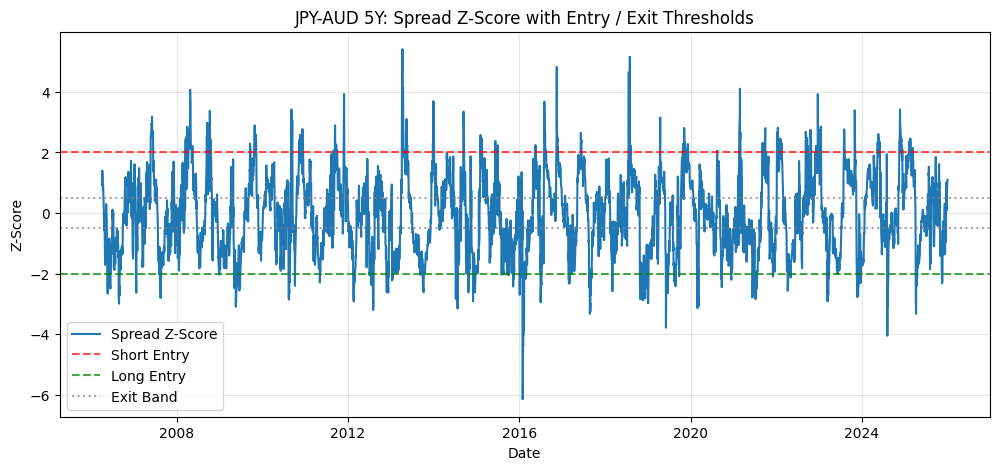

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["spread_z"], label="Spread Z-Score")
plt.axhline(ENTRY_Z, linestyle="--", color="red", alpha=0.7, label="Short Entry")
plt.axhline(-ENTRY_Z, linestyle="--", color="green", alpha=0.7, label="Long Entry")
plt.axhline(EXIT_Z, linestyle=":", color="grey", alpha=0.7, label="Exit Band")
plt.axhline(-EXIT_Z, linestyle=":", color="grey", alpha=0.7)
plt.title(f"{PAIR_ID}: Spread Z-Score with Entry / Exit Thresholds")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
"""
MIN_PROB_REVERT = 0.55

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["prob_revert"], label="OU Reversion Probability")
plt.axhline(MIN_PROB_REVERT, linestyle="--", color="red", alpha=0.7, label="Min Reversion Probability")
plt.title(f"{PAIR_ID}: OU-Based Reversion Probability")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
"""

# Create a summary of OU stats per regime
regime_summary = ou_df[['regime', 'mu', 'kappa', 'sigma', 'half_life']].copy()

# Add the expected reversion probability for each regime based on your 1.0 std dev band
regime_summary['Expected_Prob'] = regime_summary.apply(
    lambda x: ou_terminal_reversion_probability(
        current_spread=x['mu'] + (x['sigma']/np.sqrt(2*x['kappa'])), # Test at 1 std dev away
        mu=x['mu'], kappa=x['kappa'], sigma=x['sigma'],
        horizon_days=max(3, int(np.ceil(3 * x['half_life']))),
        band_width=x['sigma'] / np.sqrt(2 * x['kappa']) # 1.0 stationary std dev
    ), axis=1
)

print("--- OU Model Parameters by Regime ---")
display(regime_summary.round(4))

--- OU Model Parameters by Regime ---


,regime,mu,kappa,sigma,half_life,Expected_Prob
0,0,0.0068,0.0185,0.3075,37.4524,0.6827


In [35]:
signal_cols = ["spread_t", "spread_z", "prob_revert", "regime", "regime_allowed", "long_signal", "short_signal", "exit_signal"]
signals_only = df.loc[df["long_signal"] | df["short_signal"] | df["exit_signal"], signal_cols]

print(f"\nTotal historical signal days: {len(signals_only)}")
print("Recent Signals:")
display(signals_only.tail(30))

output_dir = ROOT / "results" / "signals"
output_dir.mkdir(parents=True, exist_ok=True) # Ensure the folder exists
save_path = output_dir / f"{PAIR_ID}_signals.parquet"

# Save the full dataframe (Notebook 16 usually needs the whole timeline, not just signal days)
df.to_parquet(save_path)
print(f"SUCCESS: Saved signals file to {save_path}")


Total historical signal days: 3180
Recent Signals:


,spread_t,spread_z,prob_revert,regime,regime_allowed,long_signal,short_signal,exit_signal
date,,,,,,,,
2025-07-31,0.177958,0.245068,0.686367,0,True,False,False,True
2025-08-01,0.157158,-0.359704,0.686377,0,True,False,False,True
2025-08-05,0.107755,-1.640303,NaN,2,False,False,False,True
2025-08-06,0.109263,-1.567571,NaN,2,False,False,False,True
2025-08-07,0.107662,-1.673850,NaN,2,False,False,False,True
2025-08-08,0.115072,-1.498857,NaN,2,False,False,False,True
2025-08-13,0.151466,-0.474742,0.686379,0,True,False,False,True
2025-08-18,0.187999,0.464748,0.686362,0,True,False,False,True
2025-09-11,0.153668,-0.326043,0.686378,0,True,False,False,True


SUCCESS: Saved signals file to C:\Users\kiefe\OneDrive\Documents\GitHub\Cross-Country-Rates-Relative-Value-NUSInvest2526\results\signals\JPY-AUD 5Y_signals.parquet


In [37]:
# Quick tally of what we're sending to Notebook 16
total_entries = df['long_signal'].sum() + df['short_signal'].sum()
print(f"Ready for Backtest: Found {total_entries} entry signals.")

if total_entries == 0:
    print("WARNING: Still no signals. Check if ENTRY_Z (currently 2.0) is too high for this spread.")
else:
    print("All systems go. Move to Notebook 16.")

Ready for Backtest: Found 224 entry signals.
All systems go. Move to Notebook 16.


## Explanation of Signal Results

The signal table shows when the USD–EUR 5Y spread satisfies all trading conditions.

Important points:

- **Regime gating matters.**  
  Even if the spread is highly dislocated, no trade is taken unless the market is in an allowed regime.

- **OU filtering matters.**  
  A large z-score alone is not sufficient. The spread must also have a sufficiently high probability of reverting within the chosen horizon.

- **Signal sparsity is desirable.**  
  Relative value strategies should not trade every day. A smaller number of high-quality convergence signals is preferable to frequent noisy trades.

This is consistent with the project’s objective of identifying when cross-country relative value relationships hold, and just as importantly, when they break

## Interpretation of Results

This notebook combines three components to construct the trading signal:

1. Spread dislocation (z-score)
2. Mean-reversion probability from the OU model
3. Regime gating from the macro regime model

Signals are only generated when **all three components align**.

---

# 1. Spread Z-Score Behaviour

The z-score plot shows the standardized deviation of the USD–EUR 5Y spread from its equilibrium level estimated using the Kalman filter.

Entry thresholds are defined as:

- **Short entry:** $z_t > 2$
- **Long entry:** $z_t < -2$

Exit threshold:

- **Exit band:** $|z_t| < 0.5$

This structure captures **large spread dislocations while exiting once most of the convergence has occurred**.

From the plot we observe:

- The spread frequently oscillates around equilibrium.
- Large deviations beyond ±2 do occur but are relatively infrequent.
- The spread often mean-reverts quickly after extreme dislocations.

This behaviour is consistent with a **stable mean-reverting relative value relationship** between USD and EUR 5Y rates.

---

# 2. OU Reversion Probability

The OU probability series measures the probability that the spread returns close to equilibrium within a given horizon.

Importantly, the model **does not use a fixed 20-day probability horizon**.

From the OU calibration in the previous notebook:

$$
\text{Half-life} \approx 1.2 \text{ days}
$$

Because the spread mean-reverts extremely quickly, using a **20-day probability horizon would be economically meaningless**.

Instead, the probability is computed using a **short adaptive horizon tied to the OU dynamics**.

---

### Observations from the Probability Plot

The probability series is concentrated around:

$$
P(\text{reversion}) \approx 0.37 - 0.39
$$

with occasional drops toward:

$$
0.28 - 0.33
$$

This indicates that:

- The spread is **mean-reverting**, but
- The probability of converging **within the short horizon and equilibrium band used in the model** is moderate rather than extremely high.

The probability filter therefore acts as a **quality filter**, distinguishing stronger convergence setups from weaker ones.

---

# 3. Probability Threshold

The current minimum probability threshold is:

$$
P(\text{revert}) > 0.55
$$

However, the empirical probability series rarely reaches this level.

This means the probability filter is **very conservative**, and in practice most trades will fail the probability screen.

This is intentional at this stage, as the probability filter is meant to be **strict before backtesting**, and can later be calibrated using out-of-sample results.

---

# 4. Regime Gating

The regime model determines whether the strategy is allowed to trade.

Only **Regime 2** satisfies the conditions where cross-country rates relative value trades historically exhibit stable cointegration.

Therefore:

- If **regime ≠ 2 → no trades allowed**
- If **regime = 2 → signals may be generated**

This ensures the strategy trades only during macro environments where the statistical relationship is historically stable.

---

# 5. Combined Signal Logic

A trade signal is generated only when all conditions hold simultaneously:

### Long Entry

1. $z_t < -2$
2. $P(\text{revert}) > P_{\min}$
3. Current regime allows trading

### Short Entry

1. $z_t > 2$
2. $P(\text{revert}) > P_{\min}$
3. Current regime allows trading

### Exit

Position is closed when:

$$
|z_t| < 0.5
$$

This ensures the trade captures the **majority of the convergence move while avoiding noise around the equilibrium level**.

---

# 6. Signal Table Interpretation

The signal table confirms that signals are extremely sparse.

This occurs because three independent filters are applied:

1. Large statistical dislocation
2. Sufficient probability of convergence
3. Correct macro regime

While this reduces trade frequency, it increases the likelihood that each trade corresponds to a **high-conviction relative value opportunity**.

---

# Conclusion

The signal design successfully integrates:

- statistical mean-reversion structure (z-score),
- stochastic OU dynamics (probability filter),
- macro regime context (regime gating).

Rather than trading every spread deviation, the strategy waits for conditions where **both the statistical structure and the macro environment support convergence**.

The next step is to translate these signals into a **portfolio trading strategy and backtest the resulting performance** by specifying:

- position direction
- sizing
- entry and exit bookkeeping
- PnL construction
- transaction costs
- performance metrics

Proceed to **Notebook 16: Backtest and Trade Construction**.